In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [24]:
df=pd.read_csv('student_performance_dirty.csv')

In [25]:
df

,StudentID,Gender,Age,StudyHours,Attendance,Marks,Grade,Pass
0,1,Male,20.0,2,80,65.0,B,Yes
1,2,Female,21.0,4,90,85.0,A,Yes
2,3,Male,19.0,3,75,58.0,C,Yes
3,4,Female,22.0,5,95,92.0,A,Yes
4,5,Male,NaN,1,60,40.0,D,No
5,6,Female,20.0,2,82,NaN,B,Yes
6,7,Male,21.0,6,98,96.0,A,Yes
7,8,Female,19.0,3,78,68.0,B,Yes
8,9,Male,20.0,2,70,55.0,C,Yes
9,10,Female,22.0,4,88,82.0,A,Yes


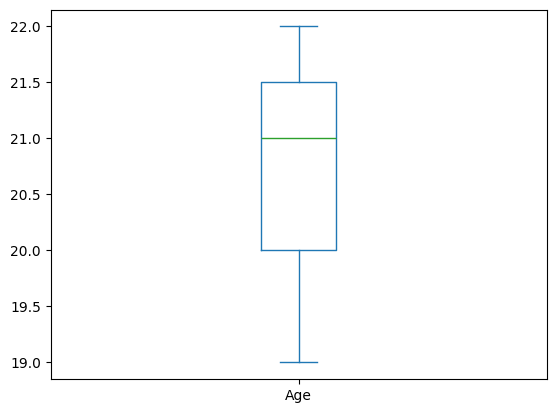

In [26]:
df['Age'].plot(kind='box')
plt.show()

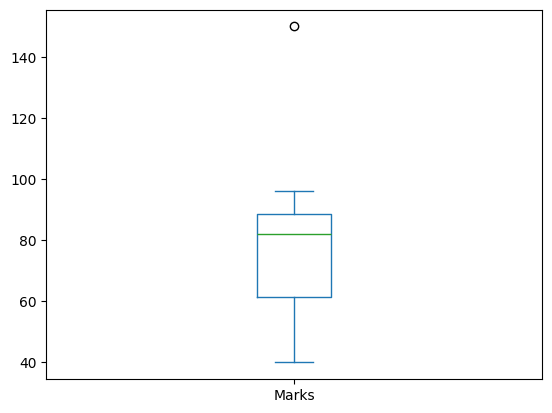

In [27]:
df['Marks'].plot(kind='box')
plt.show()

In [28]:
ageMean=df['Age'].mean().astype(int)

In [29]:
df['Age']=df['Age'].fillna(ageMean)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   12 non-null     int64  
 1   Gender      12 non-null     str    
 2   Age         12 non-null     float64
 3   StudyHours  12 non-null     int64  
 4   Attendance  12 non-null     int64  
 5   Marks       11 non-null     float64
 6   Grade       12 non-null     str    
 7   Pass        12 non-null     str    
dtypes: float64(2), int64(3), str(3)
memory usage: 900.0 bytes


In [31]:
marksMedian=df['Marks'].median()

In [32]:
df['Marks']=df['Marks'].fillna(marksMedian)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   12 non-null     int64  
 1   Gender      12 non-null     str    
 2   Age         12 non-null     float64
 3   StudyHours  12 non-null     int64  
 4   Attendance  12 non-null     int64  
 5   Marks       12 non-null     float64
 6   Grade       12 non-null     str    
 7   Pass        12 non-null     str    
dtypes: float64(2), int64(3), str(3)
memory usage: 900.0 bytes


### Analysis

In [34]:
import seaborn as sns

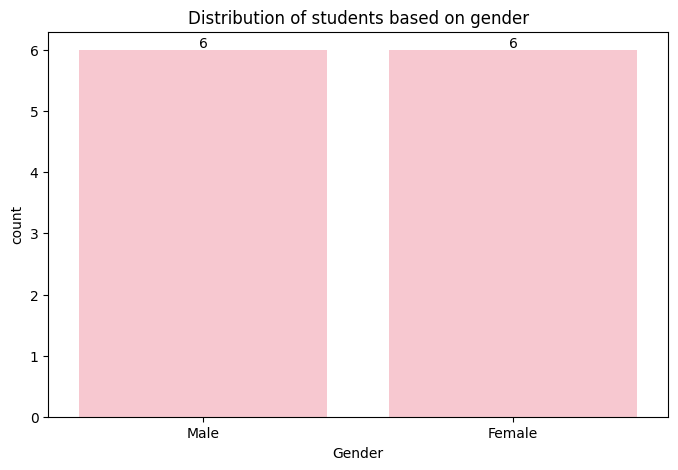

In [35]:
# 1. What is the gender distribution of students? Are male and female students equally represented?


plt.figure(figsize=(8,5))
c=sns.countplot(data=df, x='Gender', color='pink')
c.bar_label(c.containers[0])

plt.title('Distribution of students based on gender')
plt.show()

### OBSERVATION:

#### From above graph we conclude that, both male and female students are equally distributed or equally in class.

In [36]:
# 2. What is the percentage of students passed or failed? Provide quick summary for management

val1=df['Pass'].value_counts()

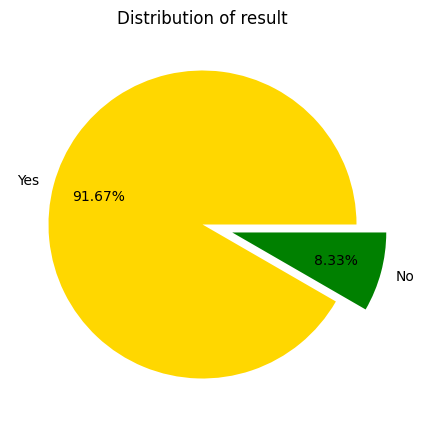

In [37]:
plt.figure(figsize=(6,5))
plt.pie(x=val1.values, labels=val1.index, colors=['gold', 'green'], autopct='%.2f%%', pctdistance=0.7, labeldistance=1.1, explode=[0,0.2])
plt.title('Distribution of result')

plt.show()

### OBSERVATION:

#### From above graph we conclude that, passing percentage is more as compare to failing one.

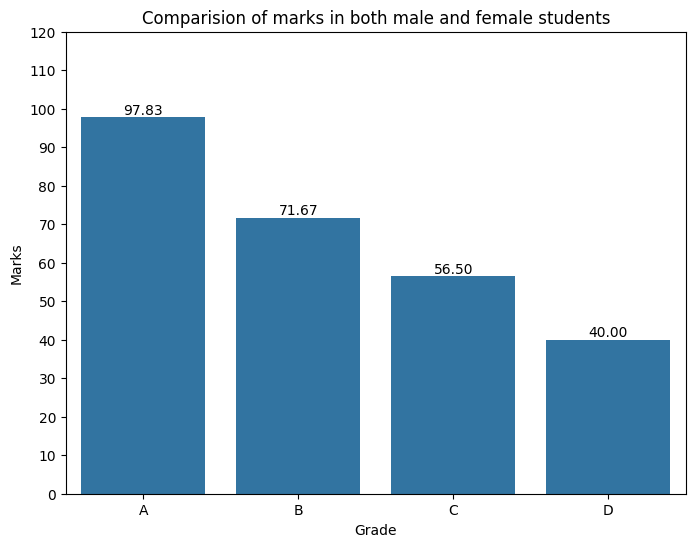

In [38]:
# 3. Which grade category has the highest average marks? Compare the average marks across all grades.
plt.figure(figsize=(8,6), )
c1=sns.barplot(data=df, y='Marks', x='Grade', errorbar=None, order=['A', 'B', 'C', 'D'])
c1.bar_label(c1.containers[0], fmt='%.2f')
plt.yticks(range(0, 130, 10))
plt.title('Comparision of marks in both male and female students')

plt.show()

### OBSERVATION:

#### From above graph we conclude that, the Grade 'A' studednts got highest average marks as compare to other grades.

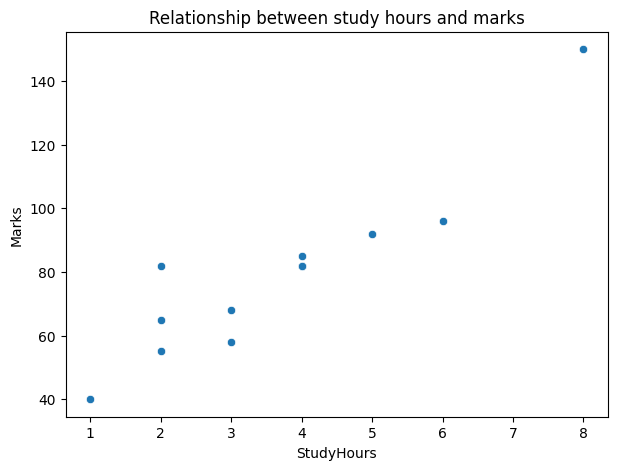

In [39]:
# 4. Does spending more time studying lead to better marks? Analyze the relationship between study hours and marks. hint:Study Hours vs Marks (Scatter Plot)

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='StudyHours', y='Marks')
plt.title('Relationship between study hours and marks')

plt.show()

### OBSERVATION:

#### From above graph we conclude that, Students who study more hours tend to achieve higher marks.

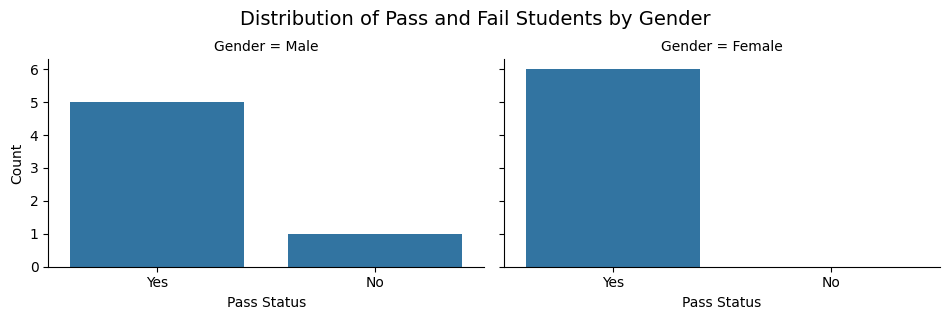

In [40]:
# 5. Is there any difference in pass and fail rates between male and female students? hint:Gender-wise Pass/Fail (FacetGrid)


fg = sns.FacetGrid(data=df, col='Gender', aspect=1.6)
fg.map_dataframe(sns.countplot, x='Pass')
fg.set_axis_labels('Pass Status', 'Count')
fg.fig.suptitle('Distribution of Pass and Fail Students by Gender',fontsize=14,y=1.05)

plt.show()

#### OBSERVATION:

##### From above graph we conclude that, Female students have a higher pass rate (100%) as comapre to Male.

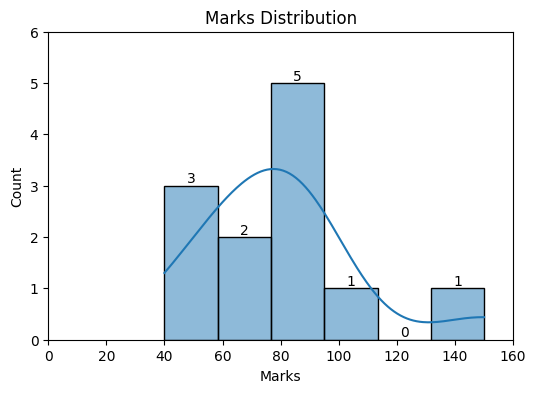

In [45]:
# 6. How are students' marks distributed? Are most students scoring high, average, or low marks? Hint:Distribution of Marks (Histogram)

plt.figure(figsize=(6,4))
cnt=sns.histplot(data=df, x='Marks', kde=True)
cnt.bar_label(cnt.containers[0])
plt.xticks(range(0, 180, 20))
plt.yticks(range(0,7,1))
plt.title('Marks Distribution')

plt.show()

### OBSERVATION:

### From above graph we conclude that, most students scored between 80 and 100 marks.

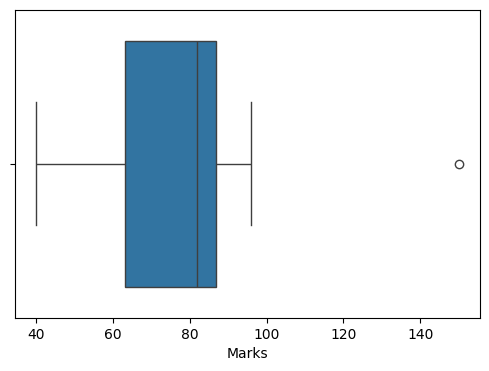

In [42]:
# 7. Are there any unusually high or low marks that could affect our analysis? hint:Detect Outliers in Marks (Boxplot)

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Marks')
# plt.yticks(range(0, 180, 20))

plt.show()

### OBSERVATION:

#### From above graph we conclude that, The boxplot reveals an unusually high mark around 150, which appears as an outlier

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   12 non-null     int64  
 1   Gender      12 non-null     str    
 2   Age         12 non-null     float64
 3   StudyHours  12 non-null     int64  
 4   Attendance  12 non-null     int64  
 5   Marks       12 non-null     float64
 6   Grade       12 non-null     str    
 7   Pass        12 non-null     str    
dtypes: float64(2), int64(3), str(3)
memory usage: 900.0 bytes


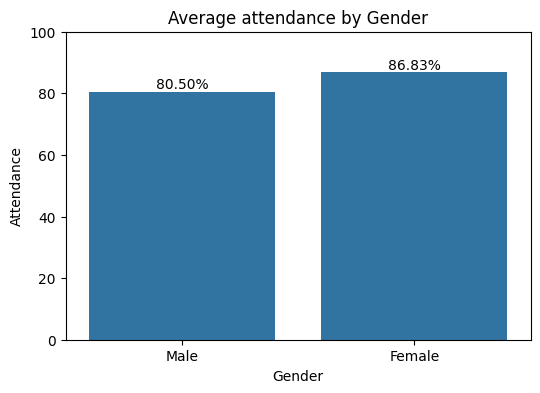

In [44]:
# 8. Which gender has better average attendance? Compare attendance across genders. hint:Average Attendance by Gender (Bar Plot)

plt.figure(figsize=(6,4))
result=sns.barplot(data=df, y='Attendance', x='Gender', errorbar=None)
result.bar_label(result.containers[0], fmt='%.2f%%')
plt.yticks(range(0,120,20))
plt.title('Average attendance by Gender')

plt.show()

### OBSERVATION:

#### From above graph we conclude that, Female students have a higher average attendance (86.83%) compared to male students (80.50%).